# The k-Nearest Neighbors (k-NN) Algorithm

In [2]:
import pandas as pd 
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [6]:
x=df.drop(columns="Outcome")
y=df["Outcome"]
print(x.shape)
y.shape

(768, 8)


(768,)

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=1,test_size=0.2)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(614, 8)
(614,)
(154, 8)
(154,)


In [13]:
# from sklearn.neighbors import KNeighborsClassifier
# nn=KNeighborsClassifier(n_neighbors=15)
# model=nn.fit(x_train,y_train)
# predection=model.predict(x_test)
# print(predection)
# alternate Way 😋😋😋
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=15)
model.fit(x_train,y_train)
predection=model.predict(x_test)
print(predection)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [18]:
diff =pd.DataFrame({"Actual":y_test,"pred":predection})
diff

,Actual,pred
285,0,1
101,0,0
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0


In [19]:
diff.to_excel("diabetes_data.xlsx")

In [20]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,predection)
print(cm)

[[89 10]
 [23 32]]


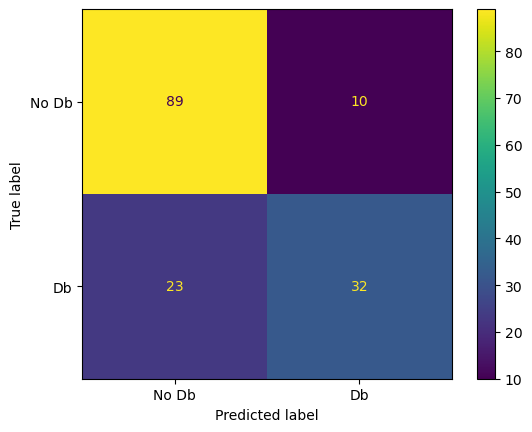

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Db","Db"])
cm_display.plot()
plt.show()

In [24]:
tn=cm[0][0]
fp=cm[0][1]
fn=cm[1][0]
tp=cm[1][1]
total=tn+fp+fn+tp
print(tn,fp,fn,tp)

89 10 23 32


### Accuracy

In [26]:
accuracy=(tn+tp)/total
print(accuracy)

0.7857142857142857


In [27]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,predection))

0.7857142857142857


### Error rate

In [28]:
error_rate=(fp+fn)/total # 1-accuracy 🙄🙄
print(error_rate)

0.21428571428571427


### Sensitivity

In [33]:
from sklearn.metrics import recall_score
print(recall_score(y_test,predection))

0.5818181818181818


In [30]:
sensitivity=(tp)/(tp+fn)
print(sensitivity)

0.5818181818181818


### Specificity

In [34]:
from sklearn.metrics import recall_score
print(recall_score(y_test,predection,pos_label=0))

0.898989898989899


In [32]:
specificity=(tn)/(tn+fp)
print(specificity)

0.898989898989899


### Precision

In [39]:
precision=(tp)/(tp+fp)
print(precision)

0.7619047619047619


In [42]:
from sklearn.metrics import precision_score
print(precision_score(y_test,predection))
print("Negative :",precision_score(y_test,predection,pos_label=0))

0.7619047619047619
Negative : 0.7946428571428571


# find k for maximuin accuracy

In [52]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
high=0
accuracy=[]
for i in range(1,154):
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train,y_train)
    predection=model.predict(x_test)
    ac=(accuracy_score(y_test,predection))
    accuracy.append(ac)
    if high<ac:
        high=ac
        k=i
print(high)
print(k)

0.7857142857142857
15


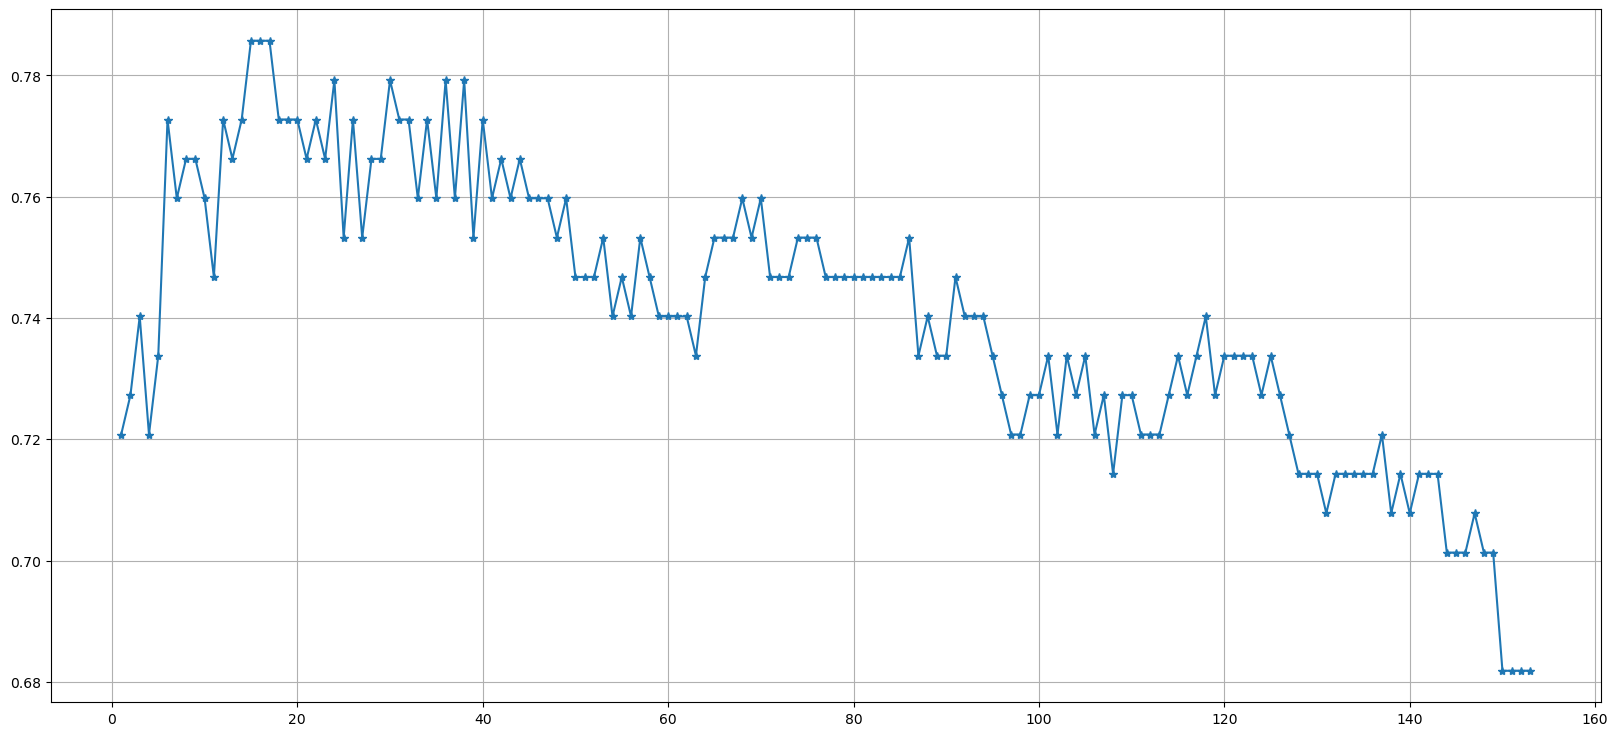

In [57]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(20,9))
plt.plot(range(1,154),accuracy,marker="*")
plt.grid(True)
plt.show()

# find k for mini 😹 accuracy

In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
mini=1
for i in range(1,154):
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train,y_train)
    predection=model.predict(x_test)
    ac=(accuracy_score(y_test,predection))
    if ac<mini:
        mini=ac
        k=i
print(mini)
print(k)

0.6818181818181818
150


# Tshirt csv

In [76]:
import pandas as pd
df=pd.read_csv("tshirt.csv")
x=df.drop(columns="Size")
y=df["Size"]


In [87]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x,y)
predection=model.predict(x)
print(predection)

['M' 'M' 'M' 'M' 'M' 'M' 'L' 'M' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L']


In [88]:
diff =pd.DataFrame({"Actual":y,"pred":predection})
diff

,Actual,pred
0,M,M
1,M,M
2,M,M
3,M,M
4,M,M
5,M,M
6,M,L
7,L,M
8,L,L
9,L,L


[[10  1]
 [ 1  6]]


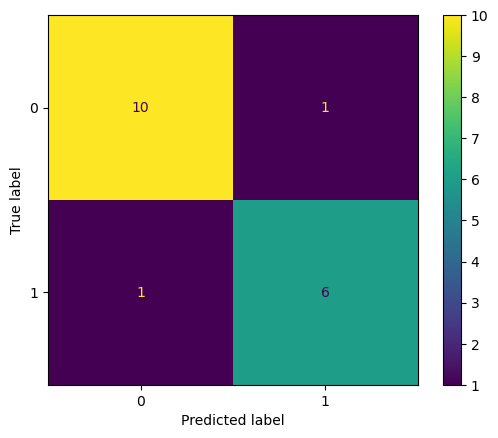

In [89]:
from sklearn.metrics import confusion_matrix
cm1=confusion_matrix(y,predection)
print(cm1)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm1,display_labels=["0","1"])
cm_display.plot()
plt.show()

In [90]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y
                     ,predection))

0.8888888888888888


# apptitute csv

In [14]:
import pandas as pd
df=pd.read_csv("AptitudeCommunication.csv")
df

,Name,Aptitude,Communication,Class
0,Karuna,2,5.0,Speaker
1,Bhavan,2,6.0,Speaker
2,Gaurav,7,6.0,Leader
3,Parul,7,2.5,Intel
4,Dinesh,8,6.0,Leader
5,Jani,4,7.0,Speaker
6,Bobby,5,3.0,Intel
7,Parimal,3,5.5,Speaker
8,Govind,8,3.0,Intel
9,Sushant,6,5.5,Leader


In [15]:
y=df["Class"]
x=df.drop(columns=["Class","Name"])

In [16]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x,y)
predection=model.predict(x)
print(predection)

['Speaker' 'Speaker' 'Leader' 'Intel' 'Leader' 'Speaker' 'Intel' 'Speaker'
 'Intel' 'Leader' 'Intel' 'Leader' 'Intel' 'Leader']


In [17]:
from sklearn.metrics import accuracy_score
print("accuracy_score :",accuracy_score(y,predection))

accuracy_score : 1.0


In [18]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,predection)
print(cm) 

[[5 0 0]
 [0 5 0]
 [0 0 4]]


# Decision Tree 
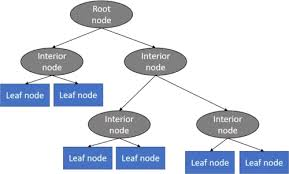

In [64]:
import pandas as pd
df=pd.read_csv("DecisionTree_Sports.csv")
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,Sunny,Hot,High,Weak,No
1,Day 2,Sunny,Hot,High,Strong,No
2,Day 3,Cloudy,Hot,High,Weak,Yes
3,Day 4,Rain,Mild,High,Weak,Yes
4,Day 5,Rain,Cool,Normal,Weak,Yes
5,Day 6,Rain,Cool,Normal,Strong,No
6,Day 7,Cloudy,Cool,Normal,Strong,Yes
7,Day 8,Sunny,Mild,High,Weak,No
8,Day 9,Sunny,Cool,Normal,Weak,Yes
9,Day 10,Rain,Mild,Normal,Weak,Yes


In [65]:
df.replace({"Sunny": 2, "Cloudy": 1, "Rain": 0 ,"Hot":2,"Mild":2,"Cool":0,"High":1,"Normal":0,"Weak":0,"Strong":1}, inplace=True)
df

C:\Users\LJENG\AppData\Local\Temp\ipykernel_8876\3213341531.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Sunny": 2, "Cloudy": 1, "Rain": 0 ,"Hot":2,"Mild":2,"Cool":0,"High":1,"Normal":0,"Weak":0,"Strong":1}, inplace=True)


,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,2,1,0,No
1,Day 2,2,2,1,1,No
2,Day 3,1,2,1,0,Yes
3,Day 4,0,2,1,0,Yes
4,Day 5,0,0,0,0,Yes
5,Day 6,0,0,0,1,No
6,Day 7,1,0,0,1,Yes
7,Day 8,2,2,1,0,No
8,Day 9,2,0,0,0,Yes
9,Day 10,0,2,0,0,Yes


In [66]:
x=df.drop(columns=["Day","Play_Sports?"])
y=df["Play_Sports?"]
print(x.shape)
y.shape

(14, 4)


(14,)

In [67]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion="entropy") # default="gini"
model=dtree.fit(x,y)
pred=model.predict(x)
pred

array(['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes',
       'Yes', 'Yes', 'Yes', 'No'], dtype=object)

In [68]:
print(dtree.get_depth())

4


In [69]:
print(dtree.get_n_leaves())

7


In [70]:
from sklearn import tree
text_representation = tree.export_text(dtree,feature_names=["Weather","Temperature","Humidity","Wind"])
print(text_representation)

|--- Humidity <= 0.50
|   |--- Weather <= 0.50
|   |   |--- Wind <= 0.50
|   |   |   |--- class: Yes
|   |   |--- Wind >  0.50
|   |   |   |--- class: No
|   |--- Weather >  0.50
|   |   |--- class: Yes
|--- Humidity >  0.50
|   |--- Weather <= 1.50
|   |   |--- Weather <= 0.50
|   |   |   |--- Wind <= 0.50
|   |   |   |   |--- class: Yes
|   |   |   |--- Wind >  0.50
|   |   |   |   |--- class: No
|   |   |--- Weather >  0.50
|   |   |   |--- class: Yes
|   |--- Weather >  1.50
|   |   |--- class: No



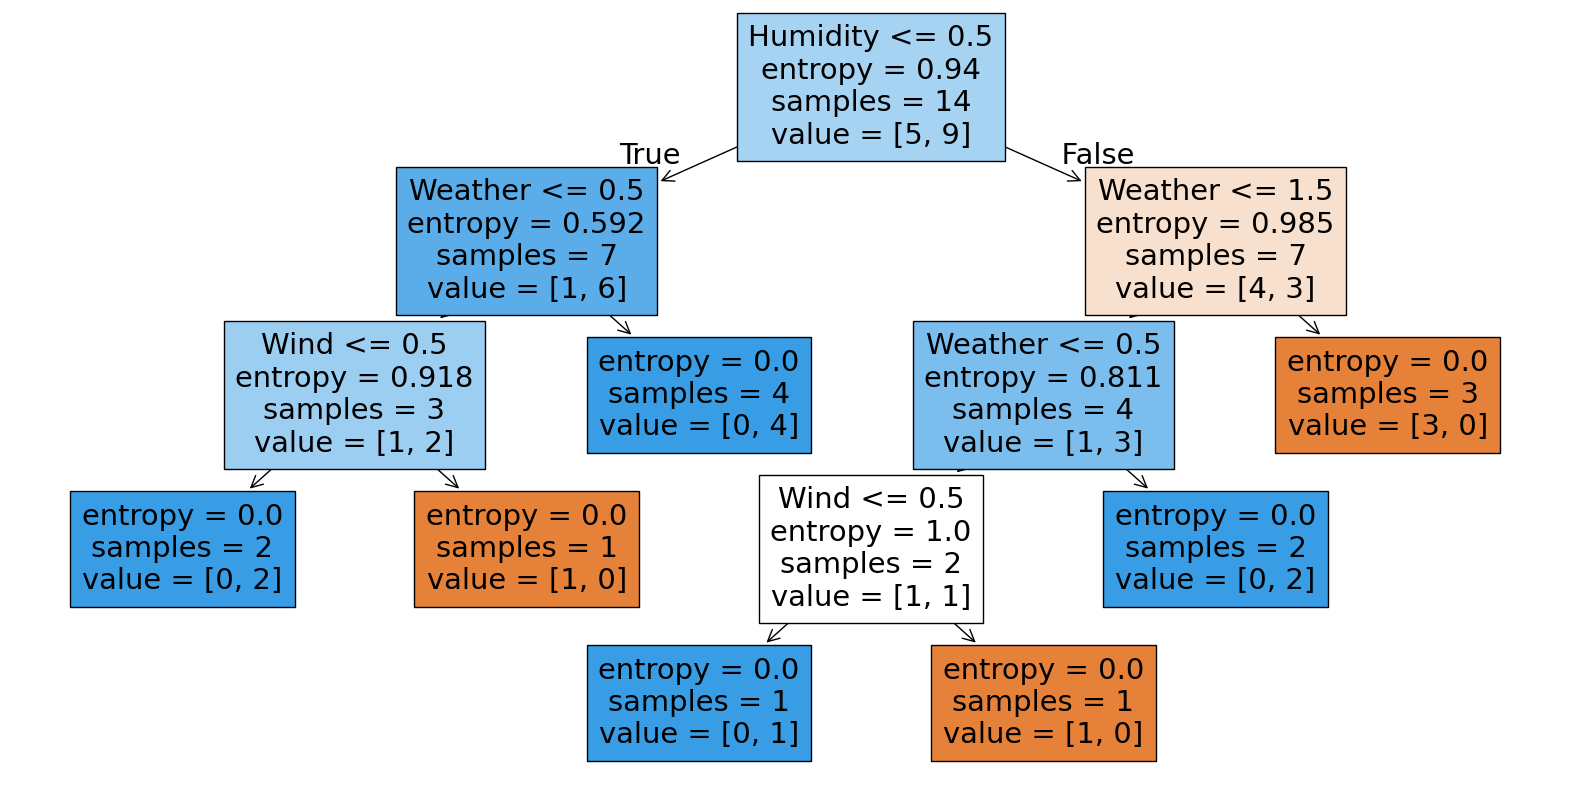

In [72]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dtree, feature_names=list(x.columns) , filled=True)
plt.show()